# NMF on Ireland-Only Corpus

**Purpose:** Train NMF on Ireland's corpus alone to discover what topics emerge when Ireland defines its own vocabulary — not measured through England's lens.

**Comparison:** England-only model (3,943 articles, k=30) vs Ireland-only model (1,036 articles, k=30)

**Key question:** Does Ireland's debate look different when it's not forced into England's topic structure?

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
from pathlib import Path
import logging
logging.basicConfig(level=logging.INFO)
logging.getLogger("gensim").setLevel(logging.WARNING)

from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

from model_pipeline.training.s02_cleaning import run_cleaning
from model_pipeline.training.s03_spacy_processing import run_spacy_processing
from model_pipeline.training.s04_vectorisation import run_vectorisation
from model_pipeline.training.s05_nmf_training import run_nmf_training, get_top_words_per_topic
from model_pipeline.training.s06_topic_allocation import TOPIC_NAMES

## 1. Load Ireland data only

In [2]:
df_irl = pd.read_csv("../../data/inference/backfill/irl_backfill.csv")
df_irl["country"] = "irl"
df_irl["text"] = df_irl["title"].fillna("") + "\n\n" + df_irl["text"].fillna("")
df_irl["date"] = pd.to_datetime(df_irl["article_date"], errors="coerce")

print(f"Ireland corpus: {len(df_irl)} articles")
print(f"By source:\n{df_irl['source'].value_counts()}")

Ireland corpus: 1036 articles
By source:
source
gov_ie               799
esri                 134
teaching_council      36
erc                   34
education_matters     33
Name: count, dtype: int64


## 2. Preprocessing

In [3]:
df_irl = run_cleaning(df_irl)
df_irl = run_spacy_processing(df_irl)
print(f"After preprocessing: {df_irl.shape}")
print(f"Empty text_final: {(df_irl['text_final'].str.len() == 0).sum()}")

INFO:model_pipeline.training.s02_cleaning:Step 02 (cleaning): starting. Input shape=(1036, 14)
INFO:model_pipeline.training.s02_cleaning:Step 02 (cleaning): complete. Output shape=(1036, 15)
INFO:model_pipeline.training.s02_cleaning:Empty cleaned texts: 0
INFO:model_pipeline.training.s03_spacy_processing:Step 03 (spacy): starting. Input shape=(1036, 15)
INFO:model_pipeline.training.s03_spacy_processing:Loading spaCy model: en_core_web_sm
INFO:model_pipeline.training.s03_spacy_processing:spaCy processing complete (tokens_after_spacy created).
INFO:model_pipeline.training.s03_spacy_processing:Post-spaCy junk filtering complete (tokens_final + text_final created).
INFO:model_pipeline.training.s03_spacy_processing:Empty text_final rows: 0
INFO:model_pipeline.training.s03_spacy_processing:Step 03 (spacy): complete. Output shape=(1036, 18)


After preprocessing: (1036, 18)
Empty text_final: 0


## 3. Vectorise + train NMF
Same specs as England model: k=30, min_df=3, max_df=0.85, max_features=3000, ngram_range=(1,2)

**Note:** 1,036 articles with k=30 means ~35 articles per topic on average. More viable than Scotland's 511 but still smaller than England's 3,943.

In [4]:
vec_out = run_vectorisation(df_irl)
nmf_out = run_nmf_training(vec_out.X, n_topics=15, random_state=42, init="nndsvd", max_iter=1000)

print(f"TF-IDF matrix: {vec_out.X.shape}")
print(f"Vocabulary size: {len(vec_out.feature_names)}")
print(f"Reconstruction error: {nmf_out.reconstruction_error:.4f}")

INFO:model_pipeline.training.s04_vectorisation:Step 04 (vectorisation): starting. Input shape=(1036, 18)
INFO:model_pipeline.training.s04_vectorisation:TF-IDF shape: (1036, 3000)
INFO:model_pipeline.training.s04_vectorisation:Vectorizer params: min_df=3 max_df=0.85 max_features=3000 ngram_range=(1, 2)
INFO:model_pipeline.training.s04_vectorisation:Sample features: ['ability', 'able', 'absence', 'abuse', 'academic', 'academic performance', 'acceptable', 'acceptance', 'acceptance necessity', 'access', 'access information', 'access work', 'accessible', 'accommodation', 'accordance', 'account', 'accountability', 'accredited', 'accredited grade', 'accurate']
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): starting. X shape=(1036, 3000)
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): complete.
INFO:model_pipeline.training.s05_nmf_training:W shape=(1036, 15) | H shape=(15, 3000)
INFO:model_pipeline.training.s05_nmf_training:Reconstruction error: 28.668969


TF-IDF matrix: (1036, 3000)
Vocabulary size: 3000
Reconstruction error: 28.6690


## 3b. Coherence sweep — find optimal k
Ireland has 1,036 articles. k=30 may work but test k=5 to k=30.

INFO:model_pipeline.training.s07_evaluation:Coherence sweep: topic_range=[5, 10, 15, 20, 25, 30]
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=5
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=10
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=15
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=20
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=25
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=30


 n_topics  coherence_cv
        5      0.635657
       10      0.574324
       15      0.599607
       20      0.574558
       25      0.567849
       30      0.568180


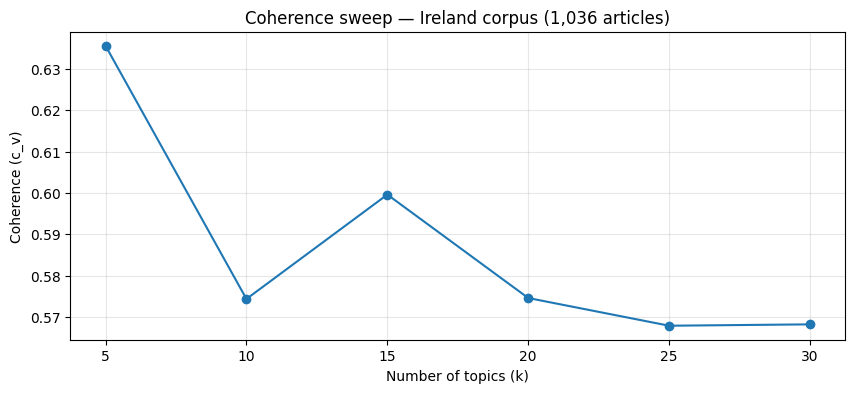


Best k: 5
Choose k based on coherence + interpretability. Update cell 3 if changing from k=30.


In [5]:
from model_pipeline.training.s07_evaluation import evaluate_coherence_over_topic_range
import matplotlib.pyplot as plt

texts_tokens = df_irl["tokens_final"].tolist()

df_coh = evaluate_coherence_over_topic_range(
    X=vec_out.X,
    feature_names=vec_out.feature_names,
    texts_tokens=texts_tokens,
    topic_range=range(5, 35, 5),
    n_top_words=10,
    random_state=42,
    init="nndsvd",
    max_iter=1000,
)

print(df_coh.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(df_coh["n_topics"], df_coh["coherence_cv"], marker="o")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence (c_v)")
plt.title("Coherence sweep — Ireland corpus (1,036 articles)")
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(range(5, 35, 5))[df_coh['coherence_cv'].argmax()]
print(f"\nBest k: {best_k}")
print("Choose k based on coherence + interpretability. Update cell 3 if changing from k=30.")


## 3c. Topic stability across random seeds

In [6]:
seeds = [42, 123, 456, 789, 1024]
H_matrices = []

for seed in seeds:
    model = NMF(n_components=nmf_out.nmf_model.n_components, init="nndsvda", random_state=seed, max_iter=1000)
    model.fit(vec_out.X)
    H_matrices.append(model.components_)
    print(f"Seed {seed}: recon error = {model.reconstruction_err_:.4f}")

pair_scores = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        sim = cosine_similarity(H_matrices[i], H_matrices[j])
        best_matches = sim.max(axis=1).mean()
        pair_scores.append(best_matches)
        print(f"Seeds {seeds[i]} vs {seeds[j]}: avg best-match = {best_matches:.4f}")

avg_stability = np.mean(pair_scores)
print(f"\nOverall topic stability: {avg_stability:.4f}")
print("Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable")


Seed 42: recon error = 28.6690
Seed 123: recon error = 28.6831
Seed 456: recon error = 28.6690
Seed 789: recon error = 28.6831
Seed 1024: recon error = 28.6831
Seeds 42 vs 123: avg best-match = 0.9659
Seeds 42 vs 456: avg best-match = 1.0000
Seeds 42 vs 789: avg best-match = 0.9659
Seeds 42 vs 1024: avg best-match = 0.9659
Seeds 123 vs 456: avg best-match = 0.9342
Seeds 123 vs 789: avg best-match = 1.0000
Seeds 123 vs 1024: avg best-match = 1.0000
Seeds 456 vs 789: avg best-match = 0.9659
Seeds 456 vs 1024: avg best-match = 0.9659
Seeds 789 vs 1024: avg best-match = 1.0000

Overall topic stability: 0.9764
Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable


## 4. Raw topic words

In [7]:
topics_irl = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=20)

print(f"{'Topic':>5}  Top 20 Words")
print("=" * 100)
for i, words in enumerate(topics_irl):
    print(f"{i:>5}  {', '.join(words)}")

Topic  Top 20 Words
    0  primary, primary school, post primary, post, teaching post, youth teaching, teaching, school, school education, primary primary, primary education, primary post, science, history, practice, additional, learning, design, additional language, questionnaire
    1  research, website, social, economic, dublin, institute, research institute, economic social, social research, policy, development, sir quay, quay dublin, sir, institute sir, quay, use, protection, governance policy, web design
    2  grade, student, certificate, mark, subject, process, examination, guide, candidate, teacher, result, school, appeal, accredited, accredited grade, sec, calculated, calculated grade, standardisation, grade certificate
    3  education youth, youth, school education, plan education, plan, education education, implementation, guideline, inspectorate, implementation plan, training, student education, publication, questionnaire, paper, education training, gaeltacht, information

## 5. Filtered top 30 words

In [8]:
display_stop = {
    "school", "education", "pupil", "student", "teacher", "year", "new", "work",
    "time", "say", "make", "good", "need", "use", "know", "want", "come", "take",
    "people", "government", "report", "system", "support", "include", "provide",
    "number", "change", "part", "set", "high", "low", "level", "national", "local",
    "public", "service", "also", "would", "could", "one", "two", "first", "last",
    "week", "month", "day", "told", "said", "according", "cent", "per", "per cent",
    "child", "children", "young", "staff", "area", "programme", "policy",
    "guidance", "framework", "response", "statement", "proposal", "approach",
    "review", "update", "document", "detail", "section", "datum", "figure",
    "survey", "rate", "score", "point", "proportion", "percentage",
    "organisation", "department", "committee", "institute", "foundation",
    "summit", "voice", "stakeholder", "partnership", "engagement",
    "scheme", "initiative", "pilot", "introduce", "implement", "launch",
    "office", "official", "notification", "recipient", "correspondence",
    "cookie", "banner", "subscribe", "contact", "submit", "accessibility",
    "share", "print", "visit", "site", "experience", "article", "news", "blog",
    "interesting", "fact", "previous", "current", "date", "information",
    "different", "large", "place", "individual", "view", "analysis",
    "thing", "way", "job"
}

topics_full = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=100)

print(f"{'Topic':>5}  Top 30 Words (display stopwords removed)")
print("=" * 140)
for i, words in enumerate(topics_full):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    print(f"{i:>5}  {', '.join(filtered)}")

Topic  Top 30 Words (display stopwords removed)
    0  primary, primary school, post primary, post, teaching post, youth teaching, teaching, school education, primary primary, primary education, primary post, science, history, practice, additional, learning, design, additional language, questionnaire, education youth, youth, personal health, equipment, social personal, furniture, health education, continuity, curriculum, personal, mathematic
    1  research, website, social, economic, dublin, research institute, economic social, social research, development, sir quay, quay dublin, sir, institute sir, quay, protection, governance policy, web design, website website, protection information, necessity, annertech, information website, dublin telephone, admin, acceptance, acceptance necessity, use acceptance, website use, telephone admin, admin governance
    2  grade, certificate, mark, subject, process, examination, guide, candidate, result, appeal, accredited, accredited grade, sec, calc

## 6. LLM-assisted naming

In [9]:
import os
from pathlib import Path
from dotenv import load_dotenv
from anthropic import Anthropic
import json
import re

load_dotenv(Path("../../.env"))
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

topic_keyword_lines = []
for i, words in enumerate(topics_full):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    topic_keyword_lines.append(f"Topic {i}: {', '.join(filtered)}")

prompt = f"""You are helping label topics from an NMF topic model trained on Irish education policy documents (2023-2025).
The corpus includes articles from Irish Government (GOV.IE), ESRI, Teaching Council, Education Research Centre, Education Matters, and RTE.

For each topic below, suggest a short descriptive name (2-4 words, snake_case) based on the keywords, and explain in one sentence why you chose it.

{chr(10).join(topic_keyword_lines)}

Return ONLY a JSON list:
[
  {{"topic": 0, "suggested_name": "name", "explanation": "why"}},
  ...
]
No other text, no markdown, no code fences."""

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=4096,
    messages=[{"role": "user", "content": prompt}],
)

llm_text = response.content[0].text
cleaned = re.sub(r'^```(?:json)?\n?', '', llm_text.strip())
cleaned = re.sub(r'\n?```$', '', cleaned.strip())
llm_results = json.loads(cleaned)

print(f"{'Topic':>5}  {'LLM Suggestion':<35}  Explanation")
print("=" * 120)
for r in llm_results:
    print(f"{r['topic']:>5}  {r['suggested_name']:<35}  {r['explanation']}")

with open("../../data/evaluation_outputs/llm_ireland_topic_review.json", "w") as f:
    json.dump(llm_results, f, indent=2)

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Topic  LLM Suggestion                       Explanation
    0  primary_curriculum_subjects          The keywords focus on primary and post-primary education with specific subjects like science, history, mathematics, and social personal health education.
    1  research_institute_governance        The keywords center around the Economic and Social Research Institute (ESRI) in Dublin and website governance policies.
    2  examination_grading_process          The keywords focus on the examination system including grades, certificates, marking, standardisation, and calculated grades.
    3  education_implementation_planning    The keywords emphasize education planning, implementation, and ministerial oversight across various educational contexts.
    4  early_childhood_inspection           The keywords focus on inspection and quality assurance in early learning and care settings.
    5  teaching_council_regulation          The keywords center on the Teaching Council's role in teacher regi

## 7. Finalise Ireland topic names

In [10]:
IRELAND_TOPIC_NAMES = {i: "TODO" for i in range(30)}

todos = [k for k, v in IRELAND_TOPIC_NAMES.items() if v == "TODO"]
if todos:
    print(f"WARNING: {len(todos)} topics still need naming")
else:
    print("All topics named.")

## 8. Topic distribution by source

In [11]:
df_irl["dominant_topic"] = nmf_out.W.argmax(axis=1)
df_irl["dominant_topic_weight"] = nmf_out.W.max(axis=1)

topic_counts = pd.Series(df_irl["dominant_topic"]).value_counts().sort_index()
print("Topic distribution:")
for t, n in topic_counts.items():
    name = IRELAND_TOPIC_NAMES.get(t, f'topic_{t}')
    print(f"  {name}: {n} ({n/len(df_irl)*100:.1f}%)")

print(f"\nDominant weight — mean: {df_irl['dominant_topic_weight'].mean():.4f}")

ct = pd.crosstab(df_irl['source'], df_irl['dominant_topic'], normalize='columns').round(2)
print("\nSource distribution per topic:")
print(ct)

Topic distribution:
  TODO: 51 (4.9%)
  TODO: 140 (13.5%)
  TODO: 67 (6.5%)
  TODO: 124 (12.0%)
  TODO: 62 (6.0%)
  TODO: 63 (6.1%)
  TODO: 41 (4.0%)
  TODO: 59 (5.7%)
  TODO: 43 (4.2%)
  TODO: 75 (7.2%)
  TODO: 59 (5.7%)
  TODO: 108 (10.4%)
  TODO: 51 (4.9%)
  TODO: 41 (4.0%)
  TODO: 52 (5.0%)

Dominant weight — mean: 0.1539

Source distribution per topic:
dominant_topic      0     1     2    3     4     5    6     7     8     9   \
source                                                                       
education_matters  0.0  0.06  0.16  0.0  0.00  0.06  0.0  0.08  0.02  0.01   
erc                0.0  0.01  0.00  0.0  0.03  0.00  0.0  0.00  0.07  0.27   
esri               0.0  0.91  0.00  0.0  0.00  0.00  0.0  0.07  0.00  0.00   
gov_ie             1.0  0.01  0.84  1.0  0.97  0.38  1.0  0.83  0.91  0.72   
teaching_council   0.0  0.00  0.00  0.0  0.00  0.56  0.0  0.02  0.00  0.00   

dominant_topic       10    11    12    13    14  
source                                     

## 9. Compare with England-only model
Which Ireland topics match England topics? Which are new?

In [12]:
import joblib

eng_nmf = joblib.load("../../experiments/outputs/runs/2026-03-20_135931/nmf_model.joblib")
eng_vec = joblib.load("../../experiments/outputs/runs/2026-03-20_135931/vectorizer.joblib")
eng_names = json.load(open("../../experiments/outputs/runs/2026-03-20_135931/topic_names.json"))
eng_features = eng_vec.get_feature_names_out()

eng_vocab = {w: i for i, w in enumerate(eng_features)}
irl_vocab = {w: i for i, w in enumerate(vec_out.feature_names)}
shared = sorted(set(eng_features) & set(vec_out.feature_names))

eng_H = np.zeros((30, len(shared)))
irl_H = np.zeros((30, len(shared)))
for j, word in enumerate(shared):
    eng_H[:, j] = eng_nmf.components_[:, eng_vocab[word]]
    irl_H[:, j] = nmf_out.H[:, irl_vocab[word]]

sim = cosine_similarity(irl_H, eng_H)

print(f"{'Ireland':>8}  {'Eng':>4}  {'Sim':>6}  {'Ireland Name':<30}  {'England Name':<30}")
print("=" * 110)
for irl_i in range(30):
    eng_i = sim[irl_i].argmax()
    s = sim[irl_i, eng_i]
    eng_name = eng_names.get(str(eng_i), eng_names.get(eng_i, '???'))
    irl_name = IRELAND_TOPIC_NAMES.get(irl_i, f'topic_{irl_i}')
    marker = '  ' if s > 0.8 else ' *' if s > 0.5 else '**'
    print(f"{irl_i:>8}  {eng_i:>4}  {s:.3f}{marker} {irl_name:<30}  {eng_name:<30}")

print(f"\nShared vocabulary: {len(shared)} / England: {len(eng_features)} / Ireland: {len(vec_out.feature_names)}")
print(f"Ireland-only words: {len(set(vec_out.feature_names) - set(eng_features))}")

ValueError: could not broadcast input array from shape (15,) into shape (30,)

## 10. Ireland-specific topics
Topics that don't match any England topic — these are what Ireland talks about that England's model can't see.

In [ ]:
print("IRELAND-SPECIFIC TOPICS (no strong England match):")
print("=" * 80)
for irl_i in range(30):
    best_sim = sim[irl_i].max()
    if best_sim < 0.5:
        irl_name = IRELAND_TOPIC_NAMES.get(irl_i, f'topic_{irl_i}')
        eng_i = sim[irl_i].argmax()
        eng_name = eng_names.get(str(eng_i), '???')
        print(f"\n{irl_name} (topic {irl_i}, best match: {eng_name} at {best_sim:.3f})")
        filtered = [w for w in topics_full[irl_i] if w not in display_stop and len(w) > 2][:20]
        print(f"  Keywords: {', '.join(filtered)}")
        source_breakdown = df_irl[df_irl['dominant_topic'] == irl_i]['source'].value_counts().to_dict()
        print(f"  Sources: {source_breakdown}")

## 11. Key findings

1. What topics does Ireland discover on its own terms that England's model can't see?
2. Does the RAAC mislabelling disappear? (Ireland's own model shouldn't have a RAAC topic)
3. Do Irish-specific concepts emerge? (DEIS, Gaeltacht, patron bodies, ETBs, Junior Cycle)
4. Which England topics have no Irish equivalent?
5. What Irish policy vocabulary enters the top 3,000 features that England's vocabulary excluded?

## 12. Save model artifacts
**Only run after finalising topic names.**

In [ ]:
import joblib
from datetime import datetime

run_id = "irl_" + datetime.now().strftime("%Y-%m-%d_%H%M%S")
run_dir = Path(f"../../experiments/outputs/runs/{run_id}")
run_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(nmf_out.nmf_model, run_dir / "nmf_model.joblib")
joblib.dump(vec_out.vectorizer, run_dir / "vectorizer.joblib")

with open(run_dir / "topic_names.json", "w") as f:
    json.dump(IRELAND_TOPIC_NAMES, f, indent=2)

metadata = {
    "run_id": run_id,
    "country": "ireland",
    "n_articles": len(df_irl),
    "n_topics": nmf_out.nmf_model.n_components,
    "reconstruction_error": float(nmf_out.reconstruction_error),
    "topic_stability": float(avg_stability),
    "corpus": "irl_backfill_511",
}
with open(run_dir / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {run_dir}")
print(f"Contents: {[f.name for f in run_dir.iterdir()]}")
